In [1]:
import scanpy as sc
print(sc.__version__)

1.11.5


/var/folders/rr/fr433gb95fv28s7v4vxmpzsc0000gn/T/ipykernel_28880/289967954.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.io
import gzip
import os

def load_sample_manual(path, sample_name):
    # Load matrix
    matrix = scipy.io.mmread(os.path.join(path, 'matrix.mtx.gz')).T.tocsr()
    
    # Load barcodes
    with gzip.open(os.path.join(path, 'barcodes.tsv.gz'), 'rt') as f:
        barcodes = [line.strip() for line in f]
    
    # Load features — only 2 columns, take gene symbols (column 1)
    with gzip.open(os.path.join(path, 'features.tsv.gz'), 'rt') as f:
        features = [line.strip().split('\t') for line in f]
    
    gene_ids = [f[0] for f in features]
    gene_symbols = [f[1] for f in features]
    
    # Build AnnData
    adata = sc.AnnData(X=matrix)
    adata.obs_names = barcodes
    adata.var_names = gene_symbols
    adata.var['gene_ids'] = gene_ids
    adata.obs['sample'] = sample_name
    adata.obs['condition'] = 'PAIVS' if 'PAIVS' in sample_name else 'Control'
    
    return adata

samples = {
    'Control1': 'data/Control1_hCM',
    'Control2': 'data/Control2_hCM',
    'PAIVS1':   'data/PAIVS1_hCM',
    'PAIVS2':   'data/PAIVS2_hCM'
}

adatas = {}
for sample_name, path in samples.items():
    adata = load_sample_manual(path, sample_name)
    adatas[sample_name] = adata
    print(f"{sample_name}: {adata.shape[0]} cells, {adata.shape[1]} genes")

Control1: 3420 cells, 33694 genes
Control2: 2393 cells, 33694 genes
PAIVS1: 4441 cells, 33694 genes
PAIVS2: 1009 cells, 33694 genes


In [3]:
import anndata
print(anndata.__version__)

0.10.7


In [4]:
# Make gene names unique within each sample first
for sample_name, adata in adatas.items():
    adata.var_names_make_unique()
    print(f"{sample_name} var names unique: {adata.var_names.is_unique}")

Control1 var names unique: True
Control2 var names unique: True
PAIVS1 var names unique: True
PAIVS2 var names unique: True


In [5]:
import anndata as ad

# Concatenate all samples into one AnnData object
adata_combined = ad.concat(adatas, label='sample')
adata_combined.var_names_make_unique()

print(adata_combined)

AnnData object with n_obs × n_vars = 11263 × 33694
    obs: 'sample', 'condition'


/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
adata_combined.write('data/combined_raw.h5ad')
print("Saved!")

Saved!


Quality Control

QC metrics: mitochondrial %, total counts, genes per cell
Filter low quality cells and doublets
This is where bad projects fail — we'll do it properly

In [7]:
# Calculate QC metrics
# Flag mitochondrial genes - they start with 'MT-'
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata_combined,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print(adata_combined.obs.columns.tolist())

['sample', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


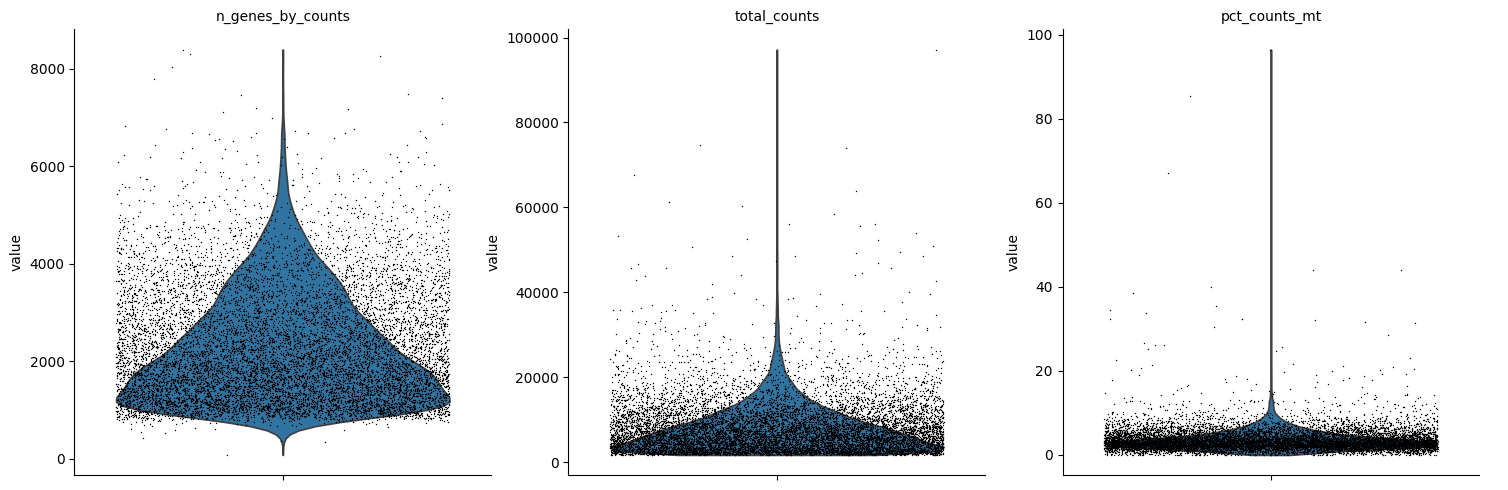

In [8]:
import matplotlib.pyplot as plt

sc.pl.violin(adata_combined, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, 
    multi_panel=True,
    save='_qc_before_filtering.png'
)

In [9]:
# Filter cells
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

# Remove high MT% cells and doublets
adata_combined = adata_combined[
    (adata_combined.obs.pct_counts_mt < 10) &
    (adata_combined.obs.n_genes_by_counts < 6000)
].copy()

print(f"Cells remaining after QC: {adata_combined.n_obs}")
print(f"Genes remaining: {adata_combined.n_vars}")

/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Cells remaining after QC: 10987
Genes remaining: 22224


/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
adata_combined.write('data/combined_filtered.h5ad')
print("Filtered data saved!")

Filtered data saved!


Normalization

In [11]:
# Normalize each cell to 10,000 total counts
sc.pp.normalize_total(adata_combined, target_sum=1e4)

# Log transform
sc.pp.log1p(adata_combined)

print("Normalization complete!")
print(adata_combined)

Normalization complete!
AnnData object with n_obs × n_vars = 10987 × 22224
    obs: 'sample', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'


Highly variable genes: 2301


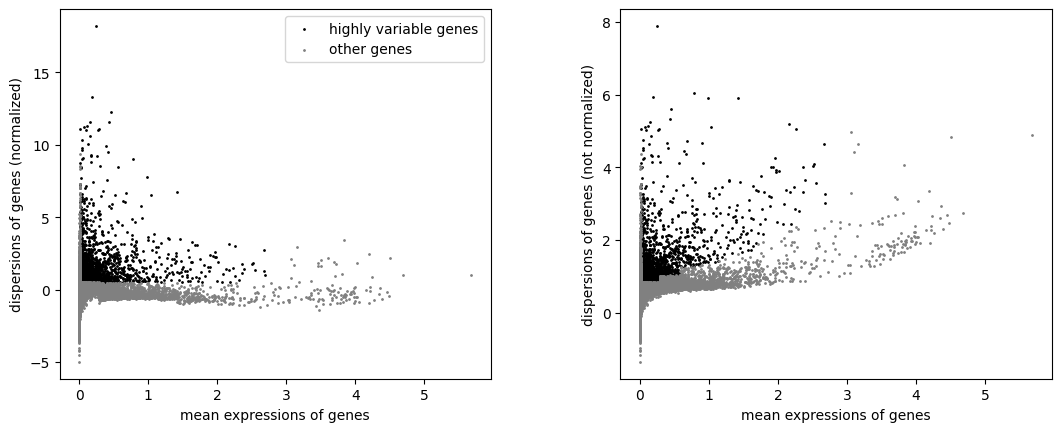

In [12]:
sc.pp.highly_variable_genes(
    adata_combined,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

print(f"Highly variable genes: {adata_combined.var.highly_variable.sum()}")

sc.pl.highly_variable_genes(adata_combined, save='_hvg.png')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


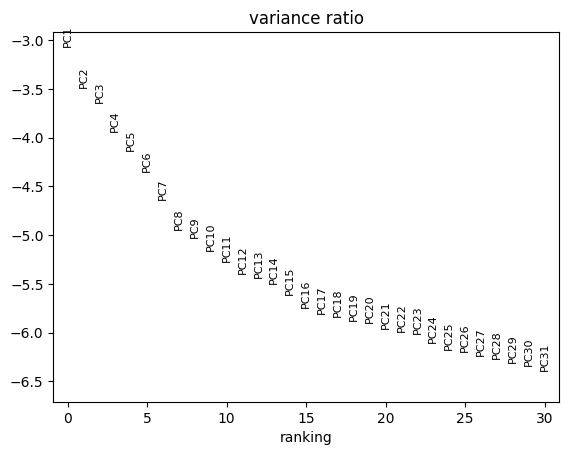

In [13]:
sc.pp.scale(adata_combined, max_value=10)
sc.tl.pca(adata_combined, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata_combined, log=True, save='_pca.png')

In [14]:
pip install igraph leidenalg

Note: you may need to restart the kernel to use updated packages.


/var/folders/rr/fr433gb95fv28s7v4vxmpzsc0000gn/T/ipykernel_28880/3720744078.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_combined, resolution=0.5)


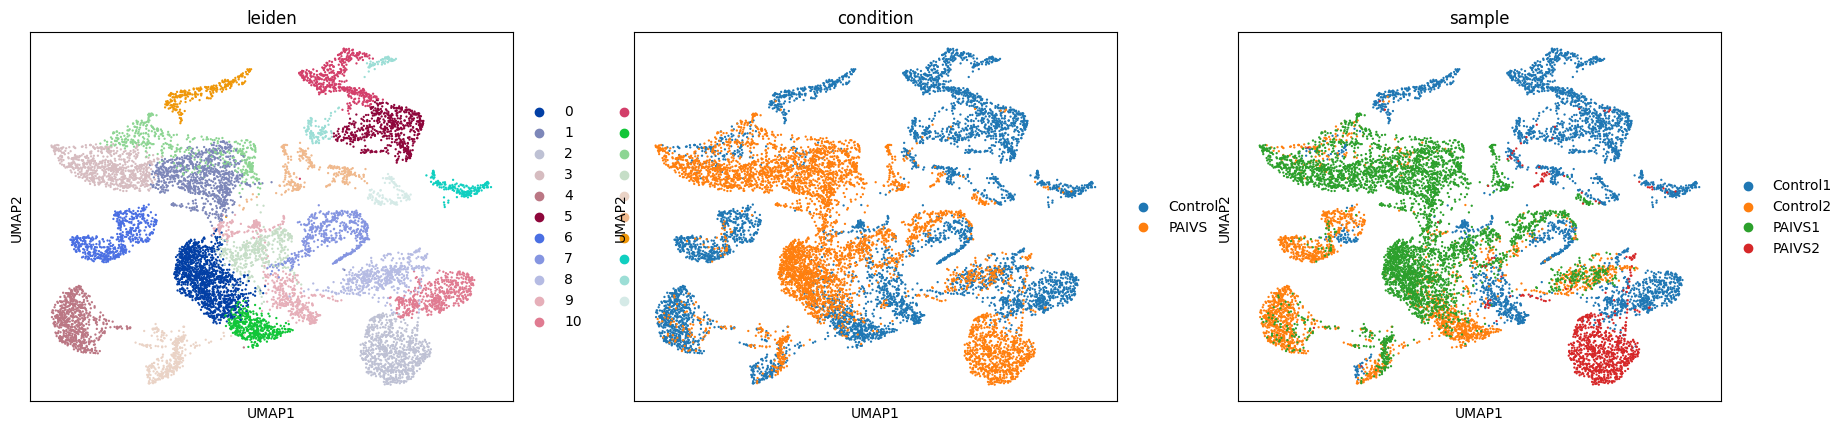

In [15]:
sc.pp.neighbors(adata_combined, n_neighbors=10, n_pcs=15)
sc.tl.umap(adata_combined)
sc.tl.leiden(adata_combined, resolution=0.5)

sc.pl.umap(adata_combined, 
    color=['leiden', 'condition', 'sample'],
    save='_clusters.png'
)

/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


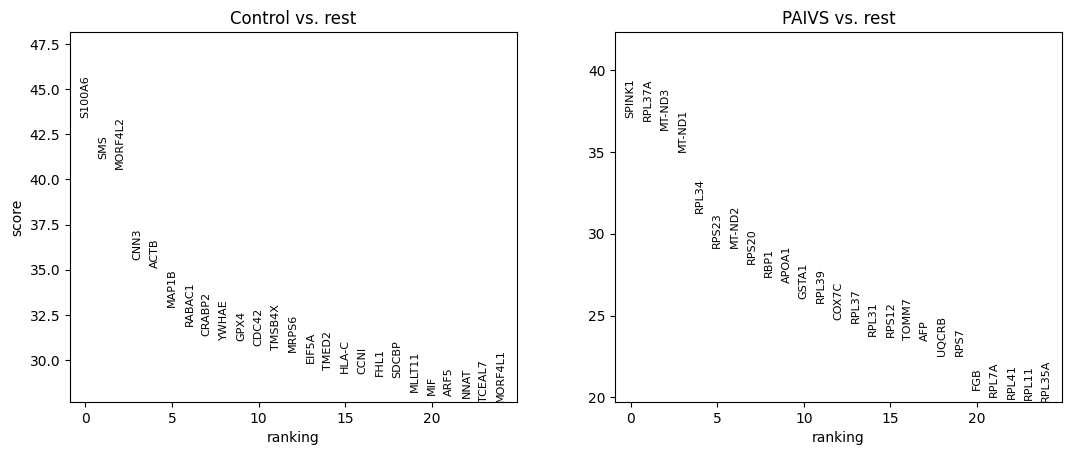

In [16]:
sc.tl.rank_genes_groups(
    adata_combined, 
    groupby='condition',
    method='wilcoxon'
)

sc.pl.rank_genes_groups(
    adata_combined, 
    n_genes=25,
    sharey=False,
    save='_marker_genes.png'
)

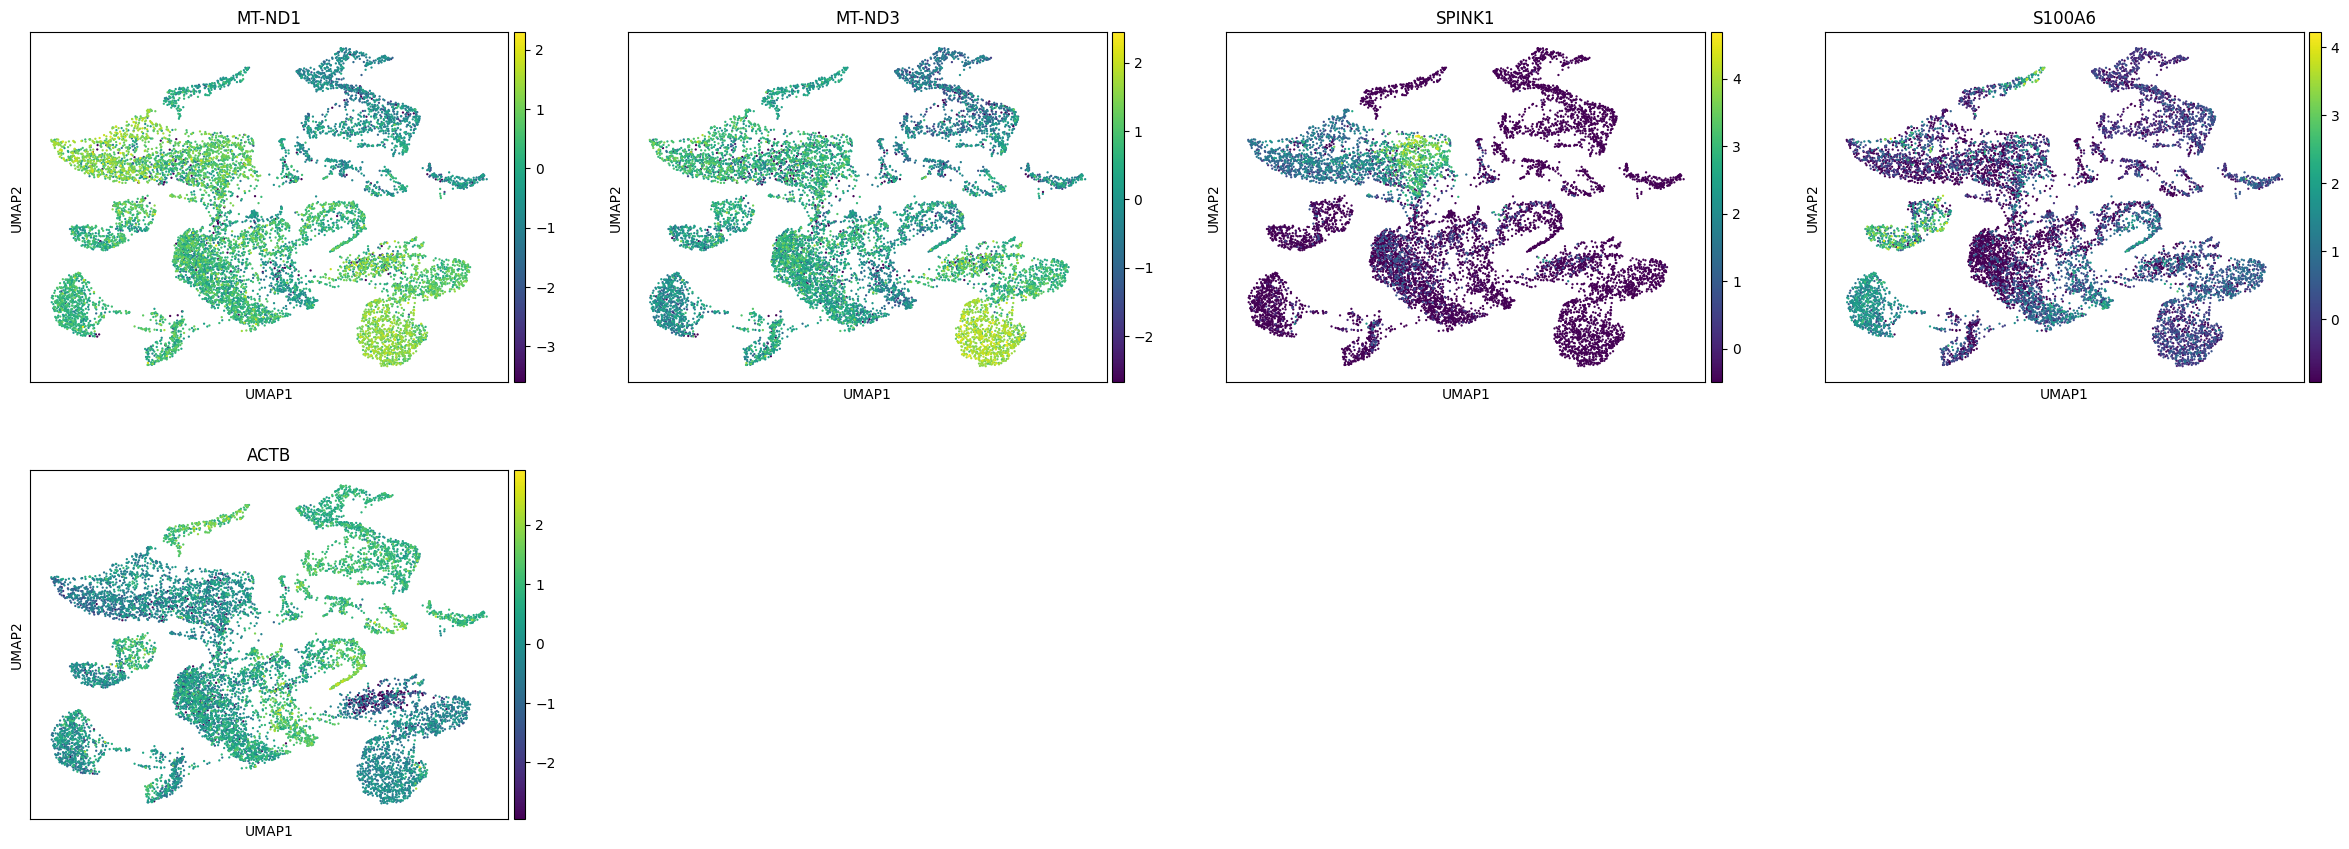

In [17]:
# Visualize key genes on UMAP
genes_of_interest = ['MT-ND1', 'MT-ND3', 'SPINK1', 'S100A6', 'ACTB']

sc.pl.umap(
    adata_combined,
    color=genes_of_interest,
    save='_gene_expression.png'
)

/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/mohammadabuhuzaifa/CHD_scRNAseq_project/scrnaseq_env/lib/pyth

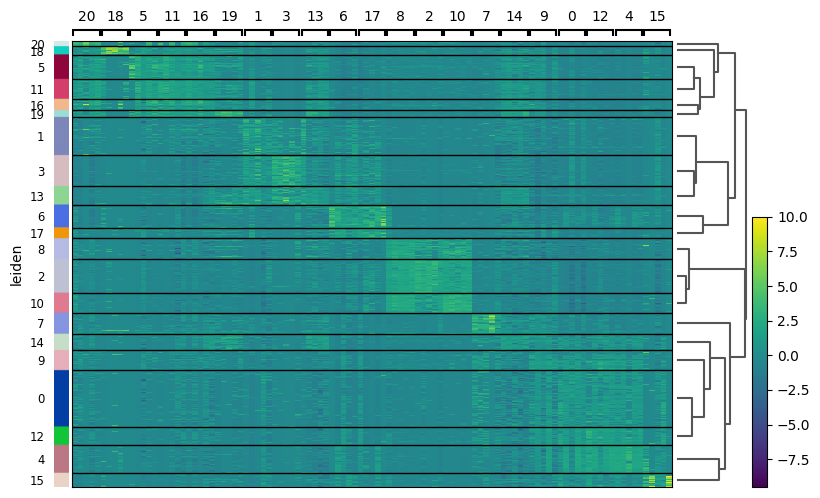

In [18]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(
    adata_combined,
    groupby='leiden',
    method='wilcoxon'
)

# Show top 5 genes per cluster
sc.pl.rank_genes_groups_heatmap(
    adata_combined,
    n_genes=5,
    groupby='leiden',
    save='_cluster_markers.png'
)

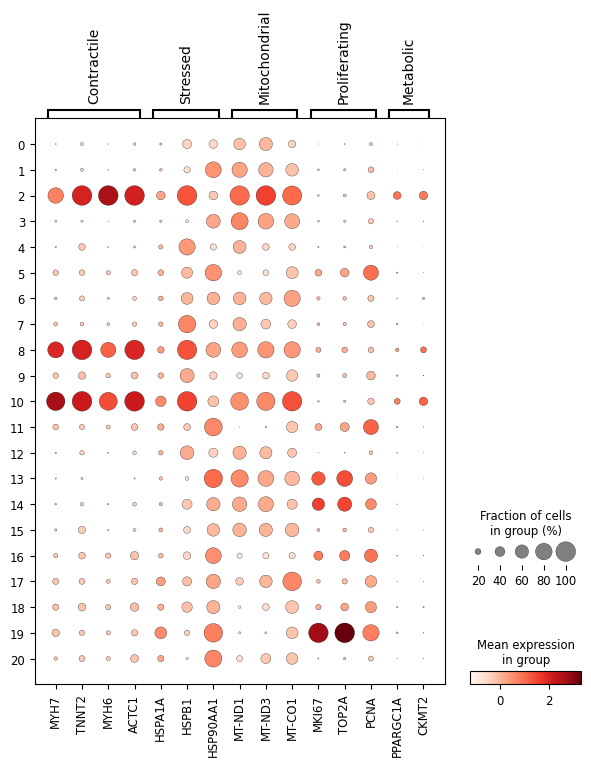

In [19]:
# Known cardiomyocyte state markers
marker_genes = {
    'Contractile': ['MYH7', 'TNNT2', 'MYH6', 'ACTC1'],
    'Stressed': ['HSPA1A', 'HSPB1', 'HSP90AA1'],
    'Mitochondrial': ['MT-ND1', 'MT-ND3', 'MT-CO1'],
    'Proliferating': ['MKI67', 'TOP2A', 'PCNA'],
    'Metabolic': ['PPARGC1A', 'CKMT2']
}

sc.pl.dotplot(
    adata_combined,
    marker_genes,
    groupby='leiden',
    save='_state_markers.png'
)

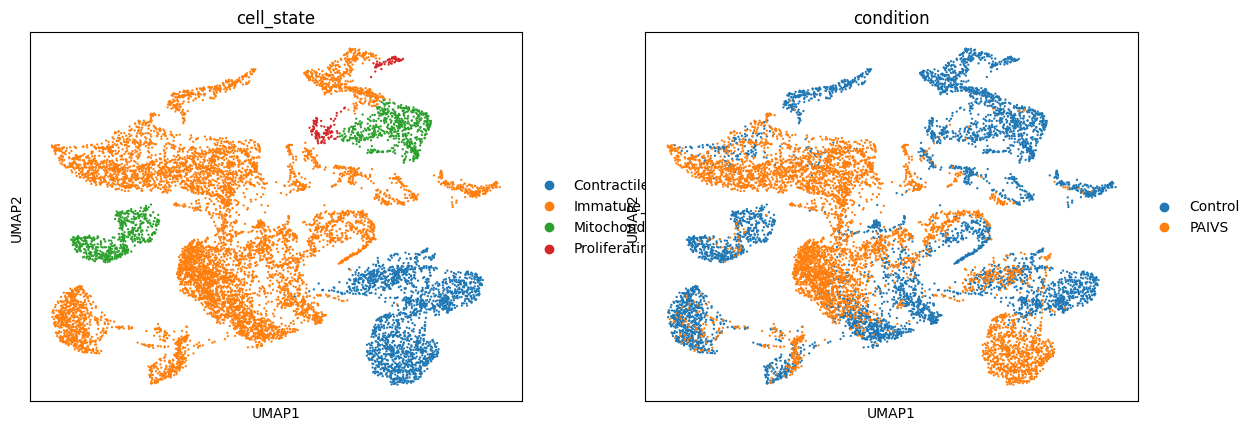

In [20]:
cluster_annotations = {
    '2': 'Contractile_CM', '8': 'Contractile_CM', '10': 'Contractile_CM',
    '19': 'Proliferating_CM',
    '5': 'Mitochondrial_CM', '6': 'Mitochondrial_CM',
    '0': 'Immature_CM', '1': 'Immature_CM', '3': 'Immature_CM',
    '4': 'Immature_CM', '7': 'Immature_CM', '9': 'Immature_CM',
    '11': 'Immature_CM', '12': 'Immature_CM', '13': 'Immature_CM',
    '14': 'Immature_CM', '15': 'Immature_CM', '16': 'Immature_CM',
    '17': 'Immature_CM', '18': 'Immature_CM', '20': 'Immature_CM'
}

adata_combined.obs['cell_state'] = adata_combined.obs['leiden'].map(cluster_annotations)

sc.pl.umap(adata_combined,
    color=['cell_state', 'condition'],
    save='_annotated.png'
)

In [21]:
# Quantify cell state proportions per condition
state_counts = adata_combined.obs.groupby(
    ['condition', 'cell_state']).size().unstack(fill_value=0)
state_props = state_counts.div(state_counts.sum(axis=1), axis=0) * 100
print(state_props.round(2))

cell_state  Contractile_CM  Immature_CM  Mitochondrial_CM  Proliferating_CM
condition                                                                  
Control              14.58        62.59             19.95              2.87
PAIVS                18.94        80.22              0.79              0.06


/var/folders/rr/fr433gb95fv28s7v4vxmpzsc0000gn/T/ipykernel_28880/360610319.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_counts = adata_combined.obs.groupby(


In [22]:
adata_combined.write('data/final_annotated.h5ad')
print("Final data saved!")

Final data saved!
